In [12]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [13]:
#here define state
class BmiState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [14]:
def calculatebmi(state:BmiState)->BmiState:
    #extract the weight and height from the state
    weight= state["weight_kg"]
    height = state["height_m"]
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)
    return state

In [15]:
def labelbmi(state:BmiState)->BmiState:
    bmi = state['bmi']
    if bmi < 18.5:
        category = 'Underweight'
    elif bmi < 25:
        category = 'Normal weight'
    elif bmi < 30:
        category = 'Overweight'
    else:
        category = 'Obesity'
    state['category'] = category
    return state

In [16]:
#define graph 
graph = StateGraph(BmiState)
#add node 
graph.add_node("calculatebmi",calculatebmi)
graph.add_node("labelbmi",labelbmi)

#add edge
graph.add_edge(START,'calculatebmi')
graph.add_edge('calculatebmi','labelbmi')
graph.add_edge('labelbmi',END)

#compile the graph
workflow=graph.compile()

In [17]:
initial_state={'weight_kg':80,'height_m':1.73}
final_state= workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


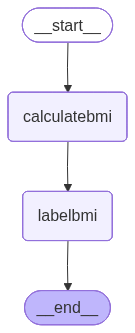

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())